Given a binary tree root, return the level order traversal of it as a nested list, where each sublist contains the values of nodes at a particular level in the tree, from left to right.

Example 1:

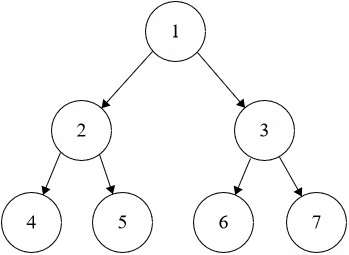

Input: root = [1,2,3,4,5,6,7]

Output: [[1],[2,3],[4,5,6,7]]

Example 2:

Input: root = [1]

Output: [[1]]

Example 3:

Input: root = []

Output: []

In [ ]:
from typing import Optional, List
from collections import deque

# BFS

Intuition

Level order traversal visits a tree level by level, from left to right.

BFS naturally fits this because it processes nodes in the order they appear using a queue.

The idea:

Push the root into the queue.

Repeatedly remove nodes from the queue, these form the current level.

Add their children into the queue, these will form the next level.

Continue until the queue is empty.

This ensures every node is visited in perfect level-order.

Algorithm

If the tree is empty, return an empty list.

Create a queue and push the root.

While the queue is not empty:

Let qLen be the number of nodes currently in the queue (these nodes form one full level).

Create an empty list level.

Repeat qLen times:

Pop a node from the queue.

Add its value to level.

Push its left and right children if they exist.

Append level to the result list.

Return the result list containing all levels.

In [ ]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def levelOrder(self, root: Optional[TreeNode]) -> List[List[int]]:
        if not root:
            return []

        result = []
        queue = deque([root])

        while queue:
            level_size = len(queue)      # how many nodes at this level?
            level_vals = []

            for _ in range(level_size):
                node = queue.popleft()  # take from front
                level_vals.append(node.val)

                if node.left:  queue.append(node.left)
                if node.right: queue.append(node.right)

            result.append(level_vals)

        return result

# DFS

Intuition

Level order traversal means visiting the tree level by level, from top to bottom.

With DFS, instead of using a queue, we use recursion and pass the current depth.

Each time we reach a node:

If this is the first time visiting this depth, create a new list for that level.

Add the node's value to the list for that depth.

Recursively explore left and right children with depth + 1.

Algorithm

Maintain an empty list res where res[d] stores all nodes at depth d.

Define a recursive function dfs(node, depth):

If node is null, return.

If res has no list for this depth, append a new empty list.

Append the node's value to res[depth].

Recurse on node.left with depth + 1.

Recurse on node.right with depth + 1.

Call dfs(root, 0).

Return res.

In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def levelOrder(self, root: Optional[TreeNode]) -> List[List[int]]:
        res = []

        def dfs(node, depth):
            if not node:
                return None
            if len(res) == depth:
                res.append([])

            res[depth].append(node.val)
            dfs(node.left, depth + 1)
            dfs(node.right, depth + 1)

        dfs(root, 0)
        return res